# Customer Churn Prediction using Machine Learning

## Project Overview

Customer churn is a major challenge for banks because retaining existing customers is significantly less expensive than acquiring new ones.

In this project, I analyze customer data from a retail bank to identify the factors associated with churn and build machine learning models capable of predicting whether a customer is likely to leave the bank.

The project follows a complete data science workflow:

- Data exploration
- Feature engineering
- Data preprocessing
- Logistic Regression
- Random Forest
- Model evaluation
- Business insights

## 1. Import Libraries

The following libraries are used for data manipulation, visualization, and machine learning.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

plt.style.use("default")

sns.set_theme(style="whitegrid")

## 2. Load Dataset

The dataset contains demographic and financial information for bank customers together with the target variable **Exited**, indicating whether the customer left the bank.

In [2]:
churn = pd.read_csv("Bank_Churn.csv")

churn.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


The dataset contains customer demographic information, account characteristics, and a binary target variable (**Exited**) that identifies whether a customer churned.

## 3. Exploratory Data Analysis (EDA)

Before building machine learning models, it is important to understand the dataset.

In this section, we examine:

- Dataset structure
- Missing values
- Summary statistics
- Target distribution
- Numerical feature distributions
- Correlations between variables

In [3]:
churn.shape

(10000, 13)

In [4]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [5]:
churn.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

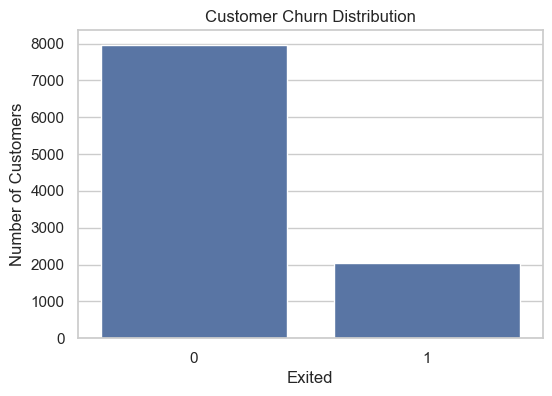

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=churn, x="Exited")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

The dataset is imbalanced.

Most customers stayed with the bank, while a smaller proportion exited. This imbalance should be considered when evaluating model performance.

In [7]:
(churn["Exited"].value_counts(normalize=True)*100).round(2)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

Approximately 80% of customers remained with the bank, while around 20% churned.

This imbalance explains why accuracy alone is not sufficient for evaluating model performance.

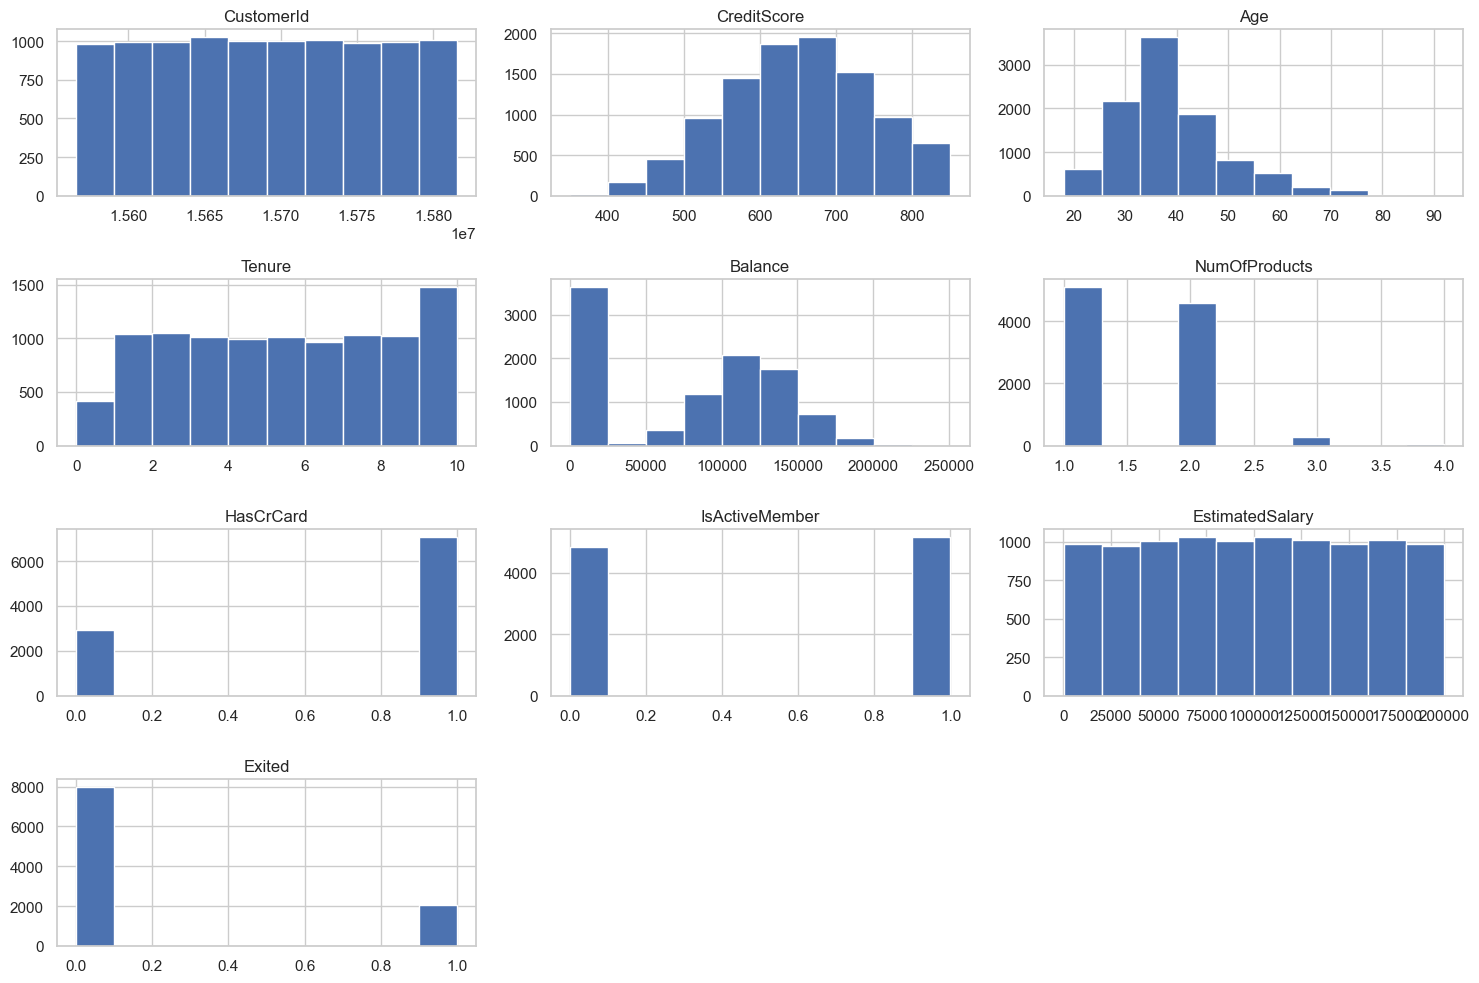

In [8]:
churn.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

The numerical variables exhibit different distributions.

Some variables, such as Age and Credit Score, appear relatively symmetric, while others like Balance contain a large concentration of zero values.

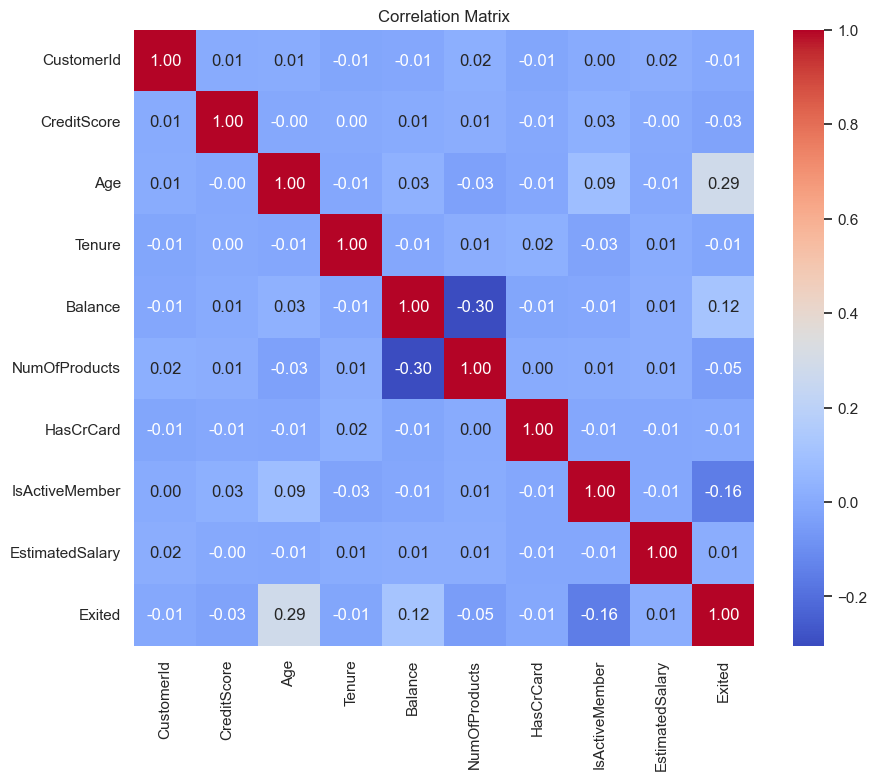

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    churn.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Most numerical variables have weak linear correlations with one another.

This indicates limited multicollinearity, which is beneficial for predictive modeling.

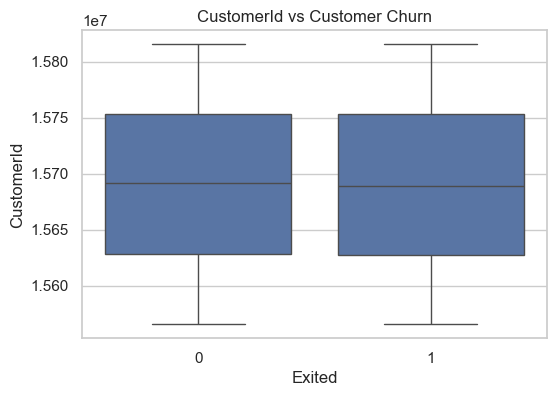

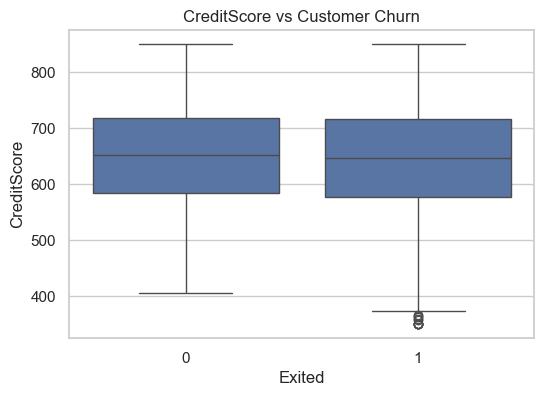

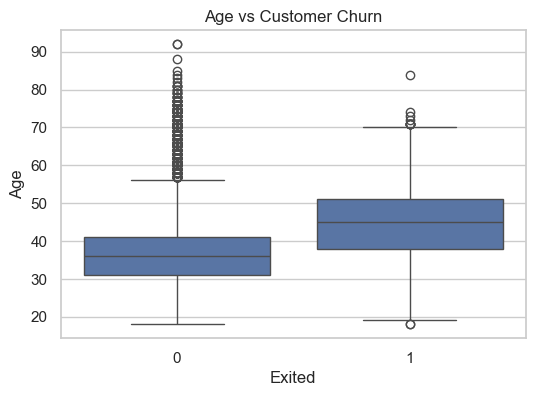

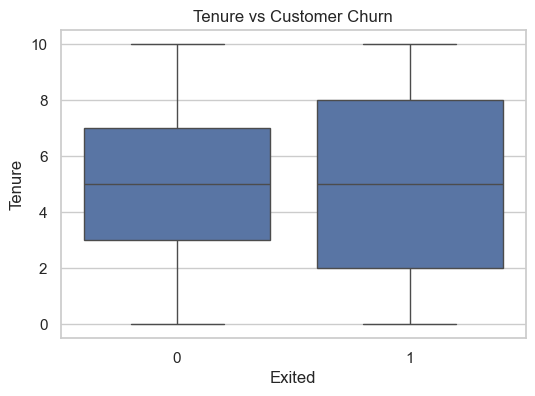

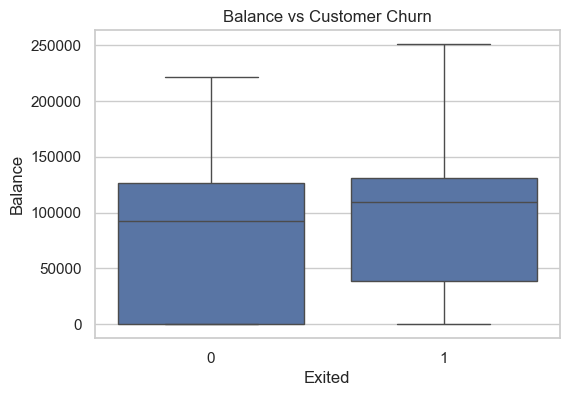

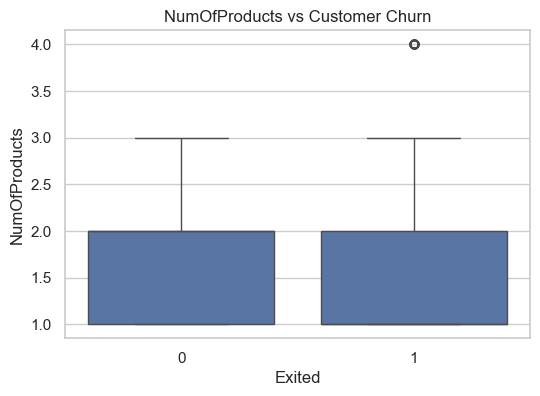

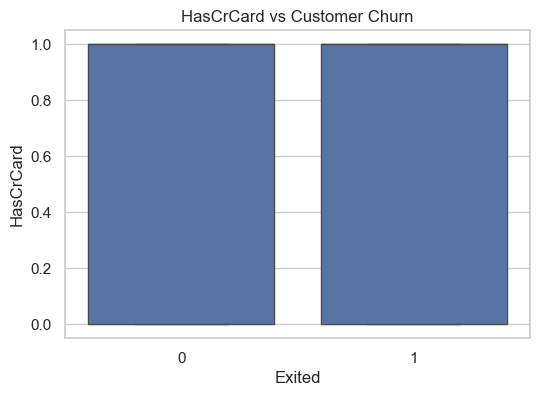

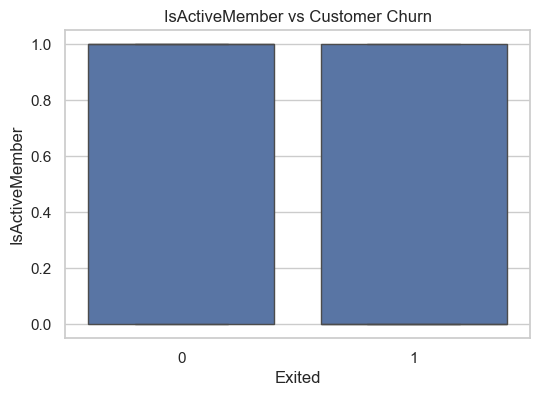

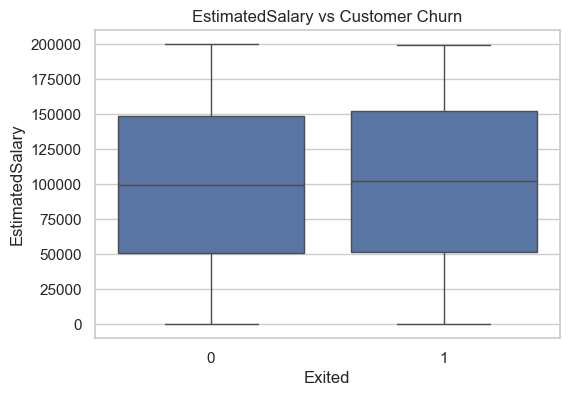

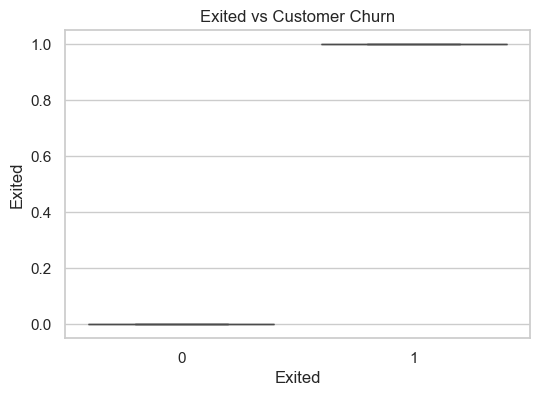

In [10]:
for col in churn.select_dtypes("number"):

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=churn,
        x="Exited",
        y=col
    )

    plt.title(f"{col} vs Customer Churn")

    plt.show()

Several numerical variables exhibit noticeable differences between customers who churned and those who remained.

In particular, Age, Balance, and Number of Products appear to influence customer churn.

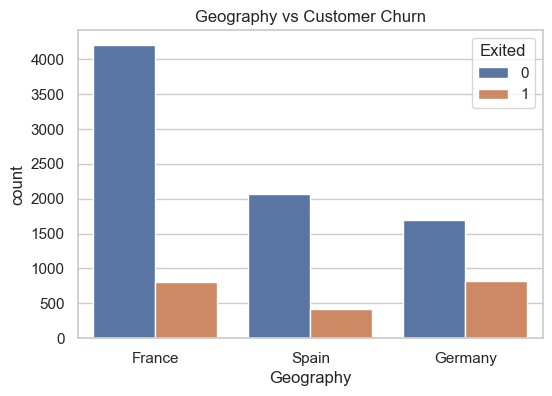

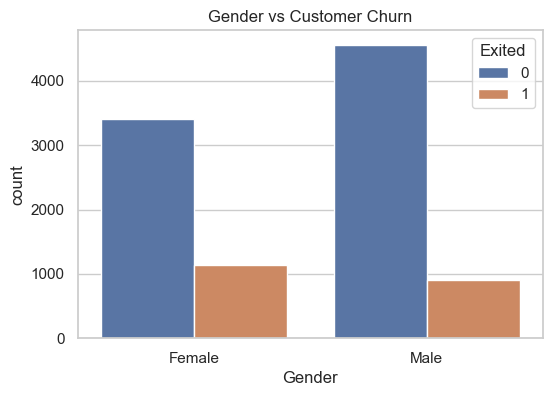

In [11]:
for col in ["Geography", "Gender"]:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=churn,
        x=col,
        hue="Exited"
    )

    plt.title(f"{col} vs Customer Churn")

    plt.show()

Customer churn varies across different geographic regions and between genders.

These categorical variables are likely to contribute useful predictive information after encoding.

# 4. Feature Engineering

Feature engineering involves creating new variables from existing data to improve predictive performance.

In this project, two new financial indicators are created:

- **Balance-to-Income Ratio** measures how much money a customer keeps in the bank relative to their estimated salary.
- **Income per Product** estimates how much income is associated with each banking product owned.

These engineered features may reveal customer behaviors that are not captured by the original variables.

In [12]:
churn_modelling_df = churn.drop(
    ["CustomerId", "Surname"],
    axis=1
)

churn_modelling_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


CustomerId and Surname are unique identifiers and do not provide predictive information for customer churn. Removing them helps reduce noise during model training.

In [13]:
churn_modelling_df = churn_modelling_df.assign(
    balance_to_income=churn_modelling_df["Balance"] /
                      churn_modelling_df["EstimatedSalary"],

    income_v_product=churn_modelling_df["EstimatedSalary"] /
                     churn_modelling_df["NumOfProducts"]
)

churn_modelling_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_income,income_v_product
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,101348.880
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677,112542.580
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375,37977.190
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,46913.315
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055,79084.100


Two additional features were created to better represent customer financial behavior.

Rather than relying only on raw balances or salaries, these engineered variables capture relationships between financial attributes that may improve model performance.

In [14]:
churn_modelling_df[
    ["balance_to_income", "income_v_product"]
].describe()

,balance_to_income,income_v_product
count,10000.000000,10000.000000
mean,3.878703,74715.158001
std,108.337260,52058.899406
min,0.000000,11.580000
25%,0.000000,32589.780000
50%,0.747002,65908.002500
75%,1.514022,100943.797500
max,10614.655440,199970.740000


The engineered variables exhibit considerable variation across customers, suggesting they may provide additional predictive information beyond the original dataset.

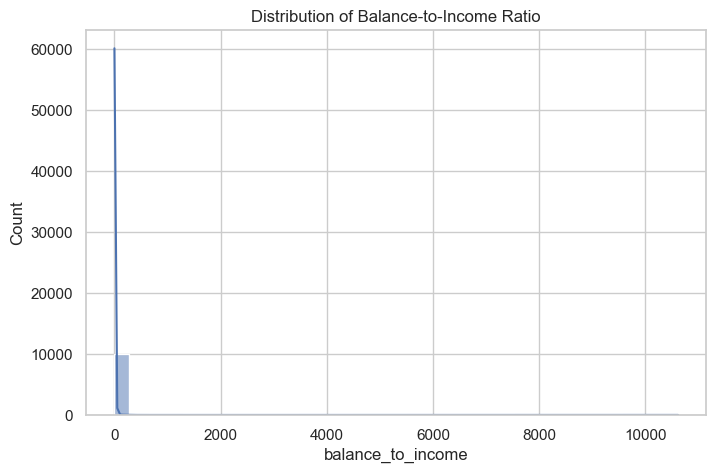

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    churn_modelling_df["balance_to_income"],
    bins=40,
    kde=True
)

plt.title("Distribution of Balance-to-Income Ratio")

plt.show()

Most customers have relatively low balance-to-income ratios, while a small number of customers have exceptionally high ratios, creating a right-skewed distribution.

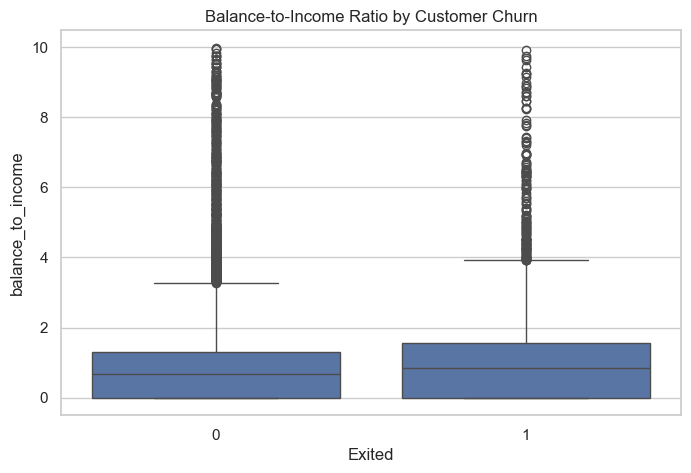

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=churn_modelling_df.query("balance_to_income < 10"),
    x="Exited",
    y="balance_to_income"
)

plt.title("Balance-to-Income Ratio by Customer Churn")

plt.show()

Customers who exited generally exhibit higher balance-to-income ratios than those who remained.

Extreme outliers were excluded to improve visualization clarity.

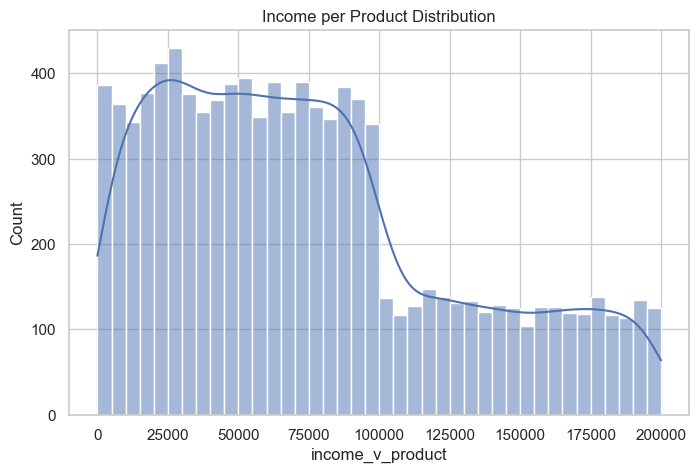

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    churn_modelling_df["income_v_product"],
    bins=40,
    kde=True
)

plt.title("Income per Product Distribution")

plt.show()

Income per Product varies substantially across customers, indicating differences in the relationship between customer income and banking product ownership.

In [18]:
churn_modelling_df = pd.get_dummies(
    churn_modelling_df,
    drop_first=True,
    dtype=int
)

churn_modelling_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_income,income_v_product,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,101348.880,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744677,112542.580,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401375,37977.190,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,46913.315,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587055,79084.100,0,1,0


Machine learning algorithms require numerical input.

Categorical variables were converted into binary indicator variables using one-hot encoding while dropping the first category to avoid multicollinearity.

# 5. Data Preparation

The dataset is divided into training and testing sets.

- **Training Set (80%)** is used to train the models.
- **Testing Set (20%)** is reserved for evaluating performance on unseen data.

In [19]:
from sklearn.model_selection import train_test_split

X = churn_modelling_df.drop("Exited", axis=1)
y = churn_modelling_df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=2024
)

In [20]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 8276 to 7816
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        8000 non-null   int64  
 1   Age                8000 non-null   int64  
 2   Tenure             8000 non-null   int64  
 3   Balance            8000 non-null   float64
 4   NumOfProducts      8000 non-null   int64  
 5   HasCrCard          8000 non-null   int64  
 6   IsActiveMember     8000 non-null   int64  
 7   EstimatedSalary    8000 non-null   float64
 8   balance_to_income  8000 non-null   float64
 9   income_v_product   8000 non-null   float64
 10  Geography_Germany  8000 non-null   int64  
 11  Geography_Spain    8000 non-null   int64  
 12  Gender_Male        8000 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 875.0 KB


The training dataset contains only numerical features, making it suitable for machine learning algorithms without requiring additional preprocessing.

# 6. Logistic Regression

Logistic Regression is a baseline classification algorithm commonly used for binary prediction problems.

It estimates the probability that a customer will churn based on the available features.

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve

In [21]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    solver="newton-cholesky"
)

lr = logreg.fit(X_train, y_train)

print(f"Training Accuracy: {lr.score(X_train, y_train):.3f}")

Training Accuracy: 0.817


The Logistic Regression model was trained using the training dataset.

Training accuracy provides an initial indication of how well the model fits the observed data.

In [22]:
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(
    y_train,
    lr.predict(X_train)
)

pd.DataFrame(
    cm_train,
    index=["Actual Stayed","Actual Churned"],
    columns=["Predicted Stayed","Predicted Churned"]
)

,Predicted Stayed,Predicted Churned
Actual Stayed,6119,253
Actual Churned,1211,417


The confusion matrix summarizes the model's predictions on the training data.

It shows the number of:

- True Positives
- True Negatives
- False Positives
- False Negatives

In [23]:
print(f"Precision : {precision_score(y_train, lr.predict(X_train)):.3f}")
print(f"Recall    : {recall_score(y_train, lr.predict(X_train)):.3f}")
print(f"F1 Score  : {f1_score(y_train, lr.predict(X_train)):.3f}")

Precision : 0.622
Recall    : 0.256
F1 Score  : 0.363


The Logistic Regression model demonstrates reasonable precision but relatively low recall.

This indicates that while many predicted churners are correct, the model fails to identify a substantial proportion of actual churning customers.

In [24]:
coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_[0]
})

coef = coef.sort_values(
    "Coefficient",
    ascending=False
)

coef

,Feature,Coefficient
4,NumOfProducts,0.798688
10,Geography_Germany,0.795574
1,Age,0.073487
11,Geography_Spain,0.035513
8,balance_to_income,0.000575
9,income_v_product,0.000022
3,Balance,0.000002
7,EstimatedSalary,-0.000017
0,CreditScore,-0.000919
2,Tenure,-0.015723


Positive coefficients increase the probability of customer churn, while negative coefficients decrease it.

These coefficients provide insight into the relationship between customer characteristics and churn behavior.

In [25]:
cm_test = confusion_matrix(
    y_test,
    lr.predict(X_test)
)

pd.DataFrame(
    cm_test,
    index=["Actual Stayed","Actual Churned"],
    columns=["Predicted Stayed","Predicted Churned"]
)

,Predicted Stayed,Predicted Churned
Actual Stayed,1536,55
Actual Churned,320,89


In [26]:
print(f"Accuracy  : {lr.score(X_test,y_test):.3f}")
print(f"Precision : {precision_score(y_test,lr.predict(X_test)):.3f}")
print(f"Recall    : {recall_score(y_test,lr.predict(X_test)):.3f}")
print(f"F1 Score  : {f1_score(y_test,lr.predict(X_test)):.3f}")

Accuracy  : 0.812
Precision : 0.618
Recall    : 0.218
F1 Score  : 0.322


Evaluation on the testing dataset measures how well the model generalizes to previously unseen customers.

Although overall accuracy is good, recall remains relatively low, suggesting that many customers who actually churn are not detected.

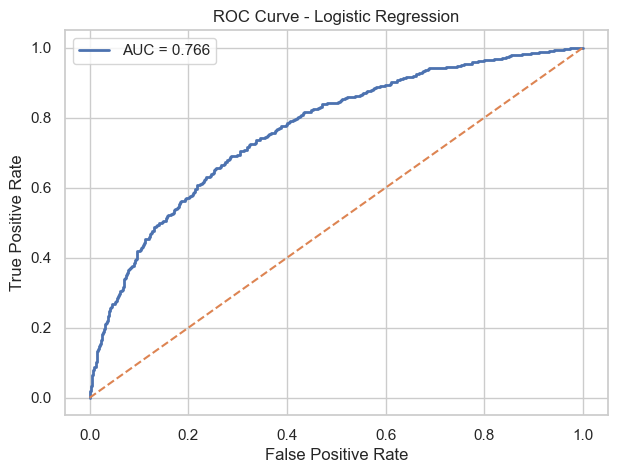

In [27]:
from sklearn.metrics import roc_curve, auc

y_probs = lr.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(
    y_test,
    y_probs
)

auc_score = auc(fpr,tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

The ROC curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

The Area Under the Curve (AUC) summarizes the model's ability to distinguish churning customers from non-churning customers.

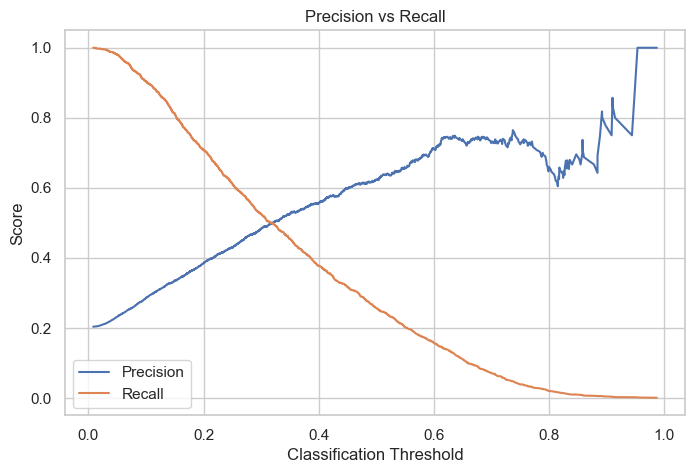

In [28]:
p_curve, r_curve, t_curve = precision_recall_curve(
    y_train,
    lr.predict_proba(X_train)[:,1]
)

plt.figure(figsize=(8,5))

plt.plot(
    t_curve,
    p_curve[:-1],
    label="Precision"
)

plt.plot(
    t_curve,
    r_curve[:-1],
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall")

plt.legend()

plt.show()

Adjusting the classification threshold changes the balance between precision and recall.

Lower thresholds generally increase recall, allowing the model to identify more churning customers at the expense of additional false positives.

In [29]:
custom_predictions = (
    lr.predict_proba(X_test)[:,1] > 0.34
)

print(
    confusion_matrix(
        y_test,
        custom_predictions
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        custom_predictions
    )
)

[[1428  163]
 [ 237  172]]
Recall: 0.42053789731051344


Lowering the decision threshold increases recall, enabling the model to identify more customers who are likely to churn.

For customer retention campaigns, maximizing recall is often more valuable than maximizing accuracy because failing to identify a customer who is about to leave can be costly.

# 7. Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

Compared to Logistic Regression, Random Forest can capture more complex relationships between customer characteristics and churn.

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    max_samples=0.5,
    min_samples_leaf=2,
    bootstrap=True,
    max_features=None,
    random_state=2023,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print(f"Training Accuracy: {rf.score(X_train, y_train):.3f}")
print(f"Testing Accuracy : {rf.score(X_test, y_test):.3f}")

Training Accuracy: 0.887
Testing Accuracy : 0.860


The tuned Random Forest achieved strong performance on both the training and testing datasets.

The relatively small difference between training and testing accuracy suggests that the model generalizes well and does not exhibit substantial overfitting.

In [31]:
cm_rf = confusion_matrix(
    y_test,
    rf.predict(X_test)
)

pd.DataFrame(
    cm_rf,
    index=["Actual Stayed","Actual Churned"],
    columns=["Predicted Stayed","Predicted Churned"]
)

,Predicted Stayed,Predicted Churned
Actual Stayed,1544,47
Actual Churned,234,175


The confusion matrix provides a detailed summary of the Random Forest model's predictions, highlighting correct classifications as well as false positives and false negatives.

In [32]:
print(f"Accuracy  : {rf.score(X_test,y_test):.3f}")
print(f"Precision : {precision_score(y_test,rf.predict(X_test)):.3f}")
print(f"Recall    : {recall_score(y_test,rf.predict(X_test)):.3f}")
print(f"F1 Score  : {f1_score(y_test,rf.predict(X_test)):.3f}")

Accuracy  : 0.860
Precision : 0.788
Recall    : 0.428
F1 Score  : 0.555


Compared with Logistic Regression, the Random Forest model achieved higher predictive performance across most evaluation metrics, making it the stronger classifier for this dataset.

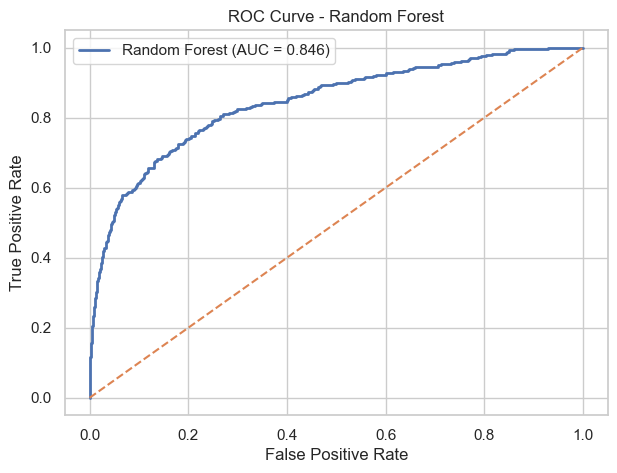

In [33]:
y_probs_rf = rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_probs_rf
)

auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

The ROC curve demonstrates the Random Forest model's ability to distinguish between customers who churn and those who remain.

A higher AUC indicates stronger discriminatory performance.

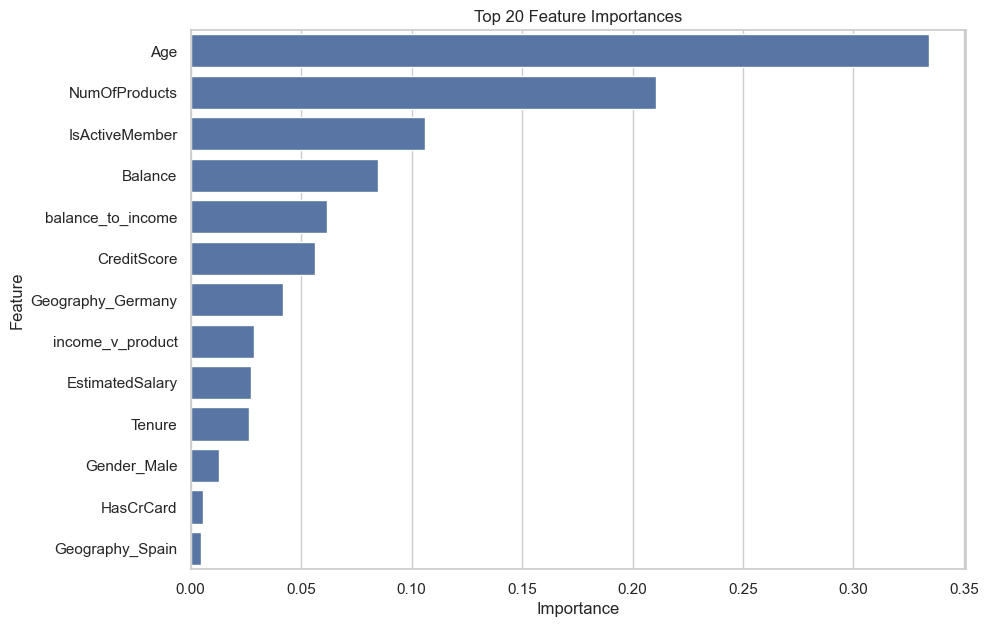

In [34]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
).head(20)

plt.figure(figsize=(10,7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances")

plt.show()

Feature importance identifies the variables that contributed most to the Random Forest predictions.

Understanding these drivers helps explain which customer characteristics are most strongly associated with churn.

# 8. Model Comparison

Both machine learning models were evaluated using the same testing dataset. Their performance was compared using four common classification metrics:

- **Accuracy** measures the overall proportion of correct predictions.
- **Precision** measures how many predicted churners actually churned.
- **Recall** measures how many actual churners were correctly identified.
- **F1 Score** balances precision and recall into a single metric.

Comparing multiple metrics provides a more complete evaluation than relying on accuracy alone.

In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr.score(X_test, y_test),
        rf.score(X_test, y_test)
    ],
    "Precision": [
        precision_score(y_test, lr.predict(X_test)),
        precision_score(y_test, rf.predict(X_test))
    ],
    "Recall": [
        recall_score(y_test, lr.predict(X_test)),
        recall_score(y_test, rf.predict(X_test))
    ],
    "F1 Score": [
        f1_score(y_test, lr.predict(X_test)),
        f1_score(y_test, rf.predict(X_test))
    ]
})

comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.812,0.618,0.218,0.322
1,Random Forest,0.860,0.788,0.428,0.555


### Model Comparison Interpretation

The Random Forest model achieved higher accuracy, precision, recall, and F1 score than Logistic Regression on the testing dataset.

Although Logistic Regression provides a useful and interpretable baseline model, Random Forest was better at capturing the complex relationships between customer characteristics and churn behavior.

Based on the evaluation metrics, **Random Forest was selected as the final model** because it provided the strongest overall predictive performance while maintaining good generalization to unseen data.

# 9. Business Insights

The analysis identified several factors associated with customer churn:

- Older customers were more likely to leave the bank.
- Customers with fewer banking products showed higher churn rates.
- Financial characteristics, including account balances and engineered financial ratios, contributed to prediction accuracy.
- Active members appeared less likely to churn.

These findings suggest that customer engagement and product adoption are important factors in customer retention.

# 10. Conclusion

This project explored customer churn using demographic, financial, and account-related data.

Key findings include:

- Random Forest outperformed Logistic Regression in predicting customer churn.
- Feature engineering improved the dataset by creating financial ratio variables.
- Customer age, number of products, account balance, and activity status were among the most influential predictors.

The final Random Forest model achieved approximately **86% test accuracy**, making it a suitable model for identifying customers who may be at risk of leaving the bank.

Banks can use this model to proactively target high-risk customers with personalized retention strategies, improving customer loyalty and reducing revenue loss.

## Future Improvements

Potential enhancements include:

- Testing Gradient Boosting models such as XGBoost or LightGBM.
- Applying cross-validation for more robust model evaluation.
- Deploying the model as an interactive web application using Streamlit.
- Monitoring model performance over time as new customer data becomes available.